## 1.原理

##### 感知机是一个线性二分类器。
##### 它找到一个超平面： w⋅x+b=0 将正负样本分开。
##### 预测规则： $\hat{y}\$ = sign(w⋅x+b)
##### 学习策略：误分类点驱动 —— 每次遇到一个预测错误的样本，就沿着梯度方向更新 w 和 b

##### 更新:
- 权重更新：$w \leftarrow w + \eta \cdot y_i \cdot x_i$
- 偏置更新：$b \leftarrow b + \eta \cdot y_i$
##### 其中 $\eta$ 是学习率，$y_i \in \{+1, -1\}$。

## 2. 生成模拟数据

##### 我们先造一个线性可分的二分类数据集，这样感知机一定能收敛

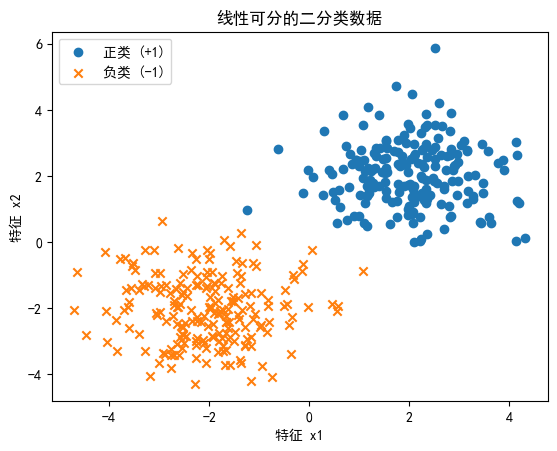

In [18]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示为方块的问题

# 设置随机种子，保证结果可复现
np.random.seed(42)

# 生成两类数据
# 类别 +1：均值为 [2, 2]，协方差为单位阵
X1 = np.random.randn(200, 2) + np.array([2, 2])
y1 = np.ones(200)

# 类别 -1：均值为 [-2, -2]，协方差为单位阵
X2 = np.random.randn(200, 2) + np.array([-2, -2])
y2 = -np.ones(200)
"""
Note: 设置正态分布的方法:
1) numpy.random.normal(loc=均值, scale=标准差, size=形状)
2) 多维:
    mean = [1, 2]
    std = [0.5, 0.3]
    X = np.random.normal(loc=mean, scale=std, size=(50, 2))
3) 线性变换
    x = mu(均值) + sigma(方差) * np.random.randn(50, 2)
"""
# 合并数据
X = np.vstack([X1, X2])
y = np.hstack([y1, y2])

# 可视化
plt.scatter(X[y==1][:,0], X[y==1][:,1], label='正类 (+1)', marker='o')
plt.scatter(X[y==-1][:,0], X[y==-1][:,1], label='负类 (-1)', marker='x')
plt.xlabel('特征 x1')
plt.ylabel('特征 x2')
plt.legend()
plt.title('线性可分的二分类数据')
plt.show()

## 3. 感知机模型实现（类封装）
##### 我们把感知机封装成一个类，包含 fit（训练）和 predict（预测）方法。

In [19]:
class Perceptron:
    """感知机分类器（原始形式）"""

    def __init__(self, learning_rate=0.02, max_epochs=1000):
        """
        参数:
        learning_rate : 学习率 eta
        max_epochs    : 最大迭代轮数（防止无限循环）
        """
        self.lr = learning_rate
        self.max_epochs = max_epochs
        self.w = None      # 权重向量
        self.b = None      # 偏置项

    def fit(self, X, y):
        """
        训练感知机
        X : 输入特征，shape (n_samples, n_features)
        y : 标签，取值 +1 或 -1，shape (n_samples,)
        """
        n_samples, n_features = X.shape

        # 初始化参数为0
        self.w = np.zeros(n_features)
        self.b = 0

        # 记录每一轮的误分类次数，用于观察
        errors_history = []

        for epoch in range(self.max_epochs):
            errors = 0
            # 遍历每个样本（随机顺序也可以，这里按原序）
            for i in range(n_samples):
                # 计算当前预测值
                linear_output = np.dot(X[i], self.w) + self.b
                y_pred = np.sign(linear_output)   # sign: 正数 -> 1, 负数 -> -1, 0 -> 0

                # 误分类条件： y_true * y_pred <= 0
                # 注意：如果 linear_output == 0， sign 返回 0，也算误分类
                if y[i] * linear_output <= 0:
                    # 更新权重和偏置
                    self.w += self.lr * y[i] * X[i]
                    self.b += self.lr * y[i]
                    errors += 1

            errors_history.append(errors)

            # 如果没有误分类点，提前停止
            if errors == 0:
                print(f"第 {epoch+1} 轮收敛，误分类数 = 0")
                break

        print(f"训练结束，共进行 {len(errors_history)} 轮，最终误分类数 = {errors_history[-1]}")
        return errors_history

    def predict(self, X):
        """预测样本类别，返回 +1 或 -1"""
        linear_out = np.dot(X, self.w) + self.b
        return np.sign(linear_out)

    def score(self, X, y):
        """计算分类准确率"""
        pred = self.predict(X)
        return np.mean(pred == y)

## 4. 训练感知机并观察结果

In [20]:
# 创建感知机实例
perceptron = Perceptron(learning_rate=0.05, max_epochs=100)

# 训练
errors_hist = perceptron.fit(X, y)

# 输出最终参数
print(f"学习到的权重 w: {perceptron.w}")
print(f"学习到的偏置 b: {perceptron.b}")

# 在训练集上的准确率
acc = perceptron.score(X, y)
print(f"训练集准确率: {acc:.2f}")

第 3 轮收敛，误分类数 = 0
训练结束，共进行 3 轮，最终误分类数 = 0
学习到的权重 w: [0.06299509 0.20157929]
学习到的偏置 b: 0.0
训练集准确率: 1.00


## 5. 可视化决策边界
##### 决策平面方程： $w_1 x_1 + w_2 x_2 + b = 0$

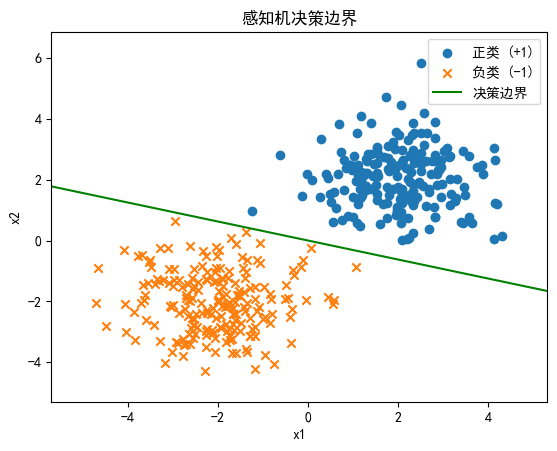

In [21]:
# 绘制数据点
plt.scatter(X[y==1][:,0], X[y==1][:,1], label='正类 (+1)', marker='o')
plt.scatter(X[y==-1][:,0], X[y==-1][:,1], label='负类 (-1)', marker='x')

# 绘制决策边界
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx = np.linspace(x_min, x_max, 100)
# 由 w1*x + w2*y + b = 0  => y = -(w1*x + b)/w2
if perceptron.w[1] != 0:
    yy = -(perceptron.w[0] * xx + perceptron.b) / perceptron.w[1]
    plt.plot(xx, yy, 'g-', label='决策边界')
else:
    # 当 w2=0 时，边界是垂直线
    plt.axvline(x=-perceptron.b/perceptron.w[0], color='g')

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('感知机决策边界')
plt.show()

### 6. 训练过程中的误分类数变化

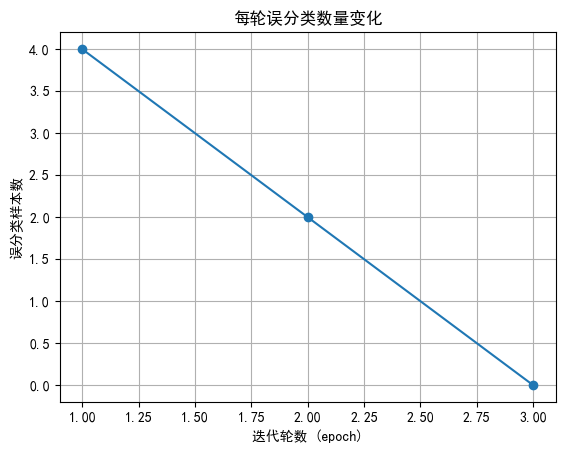

In [22]:
plt.plot(range(1, len(errors_hist)+1), errors_hist, marker='o')
plt.xlabel('迭代轮数 (epoch)')
plt.ylabel('误分类样本数')
plt.title('每轮误分类数量变化')
plt.grid(True)
plt.show()

### 7. 重点代码细节解释（对照公式理解）

| 代码片段 | 对应公式 / 作用 |
|:---|:---|
| `linear_output = np.dot(X[i], self.w) + self.b` | 计算 w · x<sub>i</sub> + b |
| `y_pred = np.sign(linear_output)` | 符号函数，得到预测类别 ŷ<sub>i</sub> (即预测的 y<sub>i</sub>) |
| `if y[i] * linear_output <= 0` | 误分类条件。注意用 linear_output 而不是 y_pred，因为当输出为 0 时也应视为错误 |
| `self.w += self.lr * y[i] * X[i]` | w ← w + η · y<sub>i</sub> · x<sub>i</sub> |
| `self.b += self.lr * y[i]` | b ← b + η · y<sub>i</sub> |
| `np.sign(self.predict(X))` | 最终预测，输出 -1 或 +1 |

### 8. 引入噪声

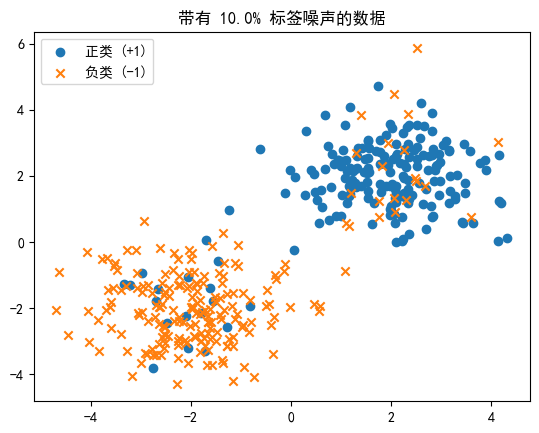

In [23]:
# ... 前面生成 X1, X2, y1, y2 的代码不变 ...

# 合并数据
X = np.vstack([X1, X2])
y = np.hstack([y1, y2])

# ---- 引入噪声：随机翻转 10% 的标签 ----
np.random.seed(42)          # 保证可复现
noise_ratio = 0.1           # 10% 噪声
n_samples = len(y)
n_noise = int(noise_ratio * n_samples)
noise_idx = np.random.choice(n_samples, n_noise, replace=False)
y[noise_idx] = -y[noise_idx]    # 标签翻转

# 可视化噪声效果
plt.scatter(X[y==1][:,0], X[y==1][:,1], label='正类 (+1)', marker='o')
plt.scatter(X[y==-1][:,0], X[y==-1][:,1], label='负类 (-1)', marker='x')
plt.title(f"带有 {noise_ratio*100}% 标签噪声的数据")
plt.legend()
plt.show()

#### 训练

In [24]:
perceptron_noisy = Perceptron(learning_rate=0.05, max_epochs=200)
errors_hist = perceptron_noisy.fit(X, y)
print(f"最终准确率: {perceptron_noisy.score(X, y):.2f}")

训练结束，共进行 200 轮，最终误分类数 = 74
最终准确率: 0.81
